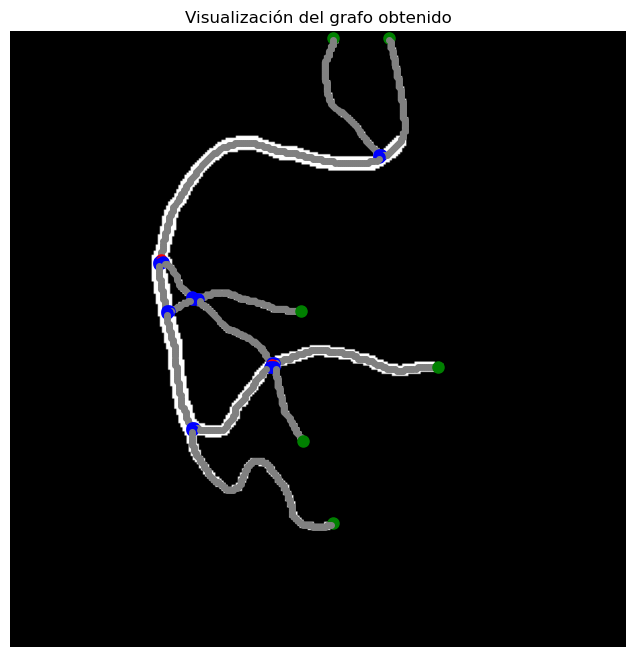

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json
from skimage.morphology import skeletonize
from scipy.signal import convolve2d

def load_image(path):
    """
    Carga una imagen en escala de grises y la binariza con un umbral fijo (127).
    Devuelve la imagen binaria en formato uint8 (0 y 255).
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    return img_bin

def get_skeleton(img_bin):
    """
    Aplica esqueletonización a la imagen binaria.
    skimage.morphology.skeletonize() requiere la imagen normalizada a [0,1].
    Devuelve el esqueleto como imagen binaria (0 y 255).
    """
    img_norm = img_bin // 255  # Normaliza a 0 o 1
    skeleton = skeletonize(img_norm).astype(np.uint8)
    return skeleton * 255  # Regresa a 0 o 255

def classify_pixels(skel):
    """
    Clasifica cada píxel del esqueleto según su número de vecinos:
    - 1 vecino: extremo (verde)
    - 2 vecinos: intermedio (gris)
    - 3 vecinos: trifurcación (azul)
    - >=4 vecinos: bifurcación (rojo)

    Devuelve:
    - Lista de nodos (diccionarios con {id, fila, columna, tipo})
    - Imagen con nodos marcados (para inspección si se desea)
    """
    # Matriz para contar vecinos (la celda central tiene valor 10)
    kernel = np.array([[1,1,1],
                       [1,10,1],
                       [1,1,1]])
    
    # Convolve2d para contar vecinos (restaremos 10 al valor central)
    conv = convolve2d(skel // 255, kernel, mode='same', boundary='fill', fillvalue=0)
    
    nodes = []
    node_img = skel.copy()
    node_id = 0

    rows, cols = skel.shape
    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if skel[i, j] > 0:  # píxel perteneciente al esqueleto
                neighbor_count = int(conv[i,j] - 10)
                
                if neighbor_count == 1:
                    tipo = "extremo"
                elif neighbor_count == 2:
                    tipo = "intermedio"
                elif neighbor_count == 3:
                    tipo = "trifurcacion"
                elif neighbor_count >= 4:
                    tipo = "bifurcacion"
                else:
                    # Si por alguna razón el conteo de vecinos es 0 (o negativo),
                    # significa que es un caso especial o error.
                    # Podrías manejarlo como "intermedio" por defecto o revisarlo.
                    tipo = "intermedio"
                
                nodes.append({
                    'id': node_id,
                    'fila': i,
                    'columna': j,
                    'tipo': tipo
                })
                node_id += 1
                
                # Para inspección, marcamos el píxel en la imagen con un valor diferente
                node_img[i, j] = 128
    
    return nodes, node_img

def construct_edges(skel, nodes):
    """
    Construye las aristas del grafo conectando nodos.
    Se usa una búsqueda local para rastrear el camino en el esqueleto
    hasta encontrar otro nodo.
    
    Devuelve un objeto grafo de networkx con:
    - nodos: 'id' (índice), atributos (fila, columna, tipo)
    - aristas: atributo 'pixels' con la lista de coordenadas que conectan esos dos nodos
    """
    # Diccionario para acceso rápido a los nodos por coordenada
    node_coords = {(n['fila'], n['columna']): n['id'] for n in nodes}
    
    # Crear grafo
    G = nx.Graph()
    for n in nodes:
        G.add_node(n['id'], fila=n['fila'], columna=n['columna'], tipo=n['tipo'])
    
    # Movimientos vecinos (8 direcciones)
    vecinos = [(-1,-1), (-1,0), (-1,1),
               (0,-1),          (0,1),
               (1,-1),  (1,0),  (1,1)]
    
    # Función para rastrear el camino en el esqueleto
    def rastrear(i, j, visitados):
        """
        Desde la coordenada (i, j), avanza por píxeles del esqueleto
        hasta encontrar otro nodo o quedarse sin vecinos. Devuelve
        el camino recorrido y el id del nodo final (o None si no se encontró).
        """
        camino = [(i,j)]
        visitados.add((i,j))
        while True:
            # Buscar vecinos válidos
            vecinos_validos = []
            for di, dj in vecinos:
                ni, nj = i+di, j+dj
                if 0 <= ni < skel.shape[0] and 0 <= nj < skel.shape[1]:
                    if skel[ni, nj] > 0 and (ni, nj) not in visitados:
                        vecinos_validos.append((ni, nj))
            
            if len(vecinos_validos) == 0:
                # No hay más camino
                break
            
            # Toma el primer vecino disponible (simplificación).
            # Podrías mejorar esto usando BFS/DFS completos.
            i, j = vecinos_validos[0]
            camino.append((i,j))
            visitados.add((i,j))
            
            # Si encontramos otro nodo, detenemos el rastreo
            if (i,j) in node_coords:
                return camino, node_coords[(i,j)]
        
        # Si salimos del while sin encontrar nodo, no hay conexión
        return camino, None
    
    visitados_global = set()
    
    for n in nodes:
        i, j = n['fila'], n['columna']
        
        # Explorar vecinos inmediatos del nodo
        for di, dj in vecinos:
            ni, nj = i+di, j+dj
            if 0 <= ni < skel.shape[0] and 0 <= nj < skel.shape[1]:
                if skel[ni, nj] > 0 and (ni, nj) not in visitados_global:
                    camino, nodo_final = rastrear(ni, nj, visitados_global)
                    if nodo_final is not None and nodo_final != n['id']:
                        # Añadir arista si no existe
                        if not G.has_edge(n['id'], nodo_final):
                            G.add_edge(n['id'], nodo_final, pixels=camino)
    
    return G

# ========== MAIN DE EJEMPLO ==========

if __name__ == "__main__":
    # Ajusta la ruta a tu imagen groundtruth
    # (asegúrate de que la imagen sea binaria, o se binarizará con threshold 127)
    nombre_imagen = os.path.join("datos", "etiquetas", "1.pgm")  # Ajustar a tu nombre de archivo
    
    # 1. Cargar imagen binaria
    img_bin = load_image(nombre_imagen)
    if img_bin is None:
        raise ValueError(f"Failed to load image from path: {nombre_imagen}")
    
    # 2. Obtener esqueleto (opcional, si ya es 1 píxel de grosor, no hace falta)
    skel = get_skeleton(img_bin)
    
    # 3. Clasificar píxeles -> nodos
    nodos, img_nodos = classify_pixels(skel)
    
    # 4. Construir grafo
    grafo = construct_edges(skel, nodos)
    
    # 5. Exportar grafo a JSON (opcional)
    grafo_json = {
        "nodos": nodos,
        "aristas": [
            {
                "nodo1": u,
                "nodo2": v,
                "camino": grafo[u][v]['pixels']
            }
            for u, v in grafo.edges()
        ]
    }
    with open("grafo_estructura.json", "w") as f:
        json.dump(grafo_json, f, indent=4)
    
    # 6. Visualizar el resultado
    plt.figure(figsize=(8, 8))
    plt.imshow(img_bin, cmap='gray')
    
    # Dibujar aristas (amarillo)
    for u, v in grafo.edges():
        camino = np.array(grafo[u][v]['pixels'])
        plt.plot(camino[:,1], camino[:,0], color='yellow', linewidth=1)
    
    # Dibujar nodos con distinto color y tamaño
    for n in nodos:
        c = n['columna']
        r = n['fila']
        if n['tipo'] == "extremo":
            plt.plot(c, r, 'o', color='green', markersize=8)   # más grande
        elif n['tipo'] == "bifurcacion":
            plt.plot(c, r, 'o', color='red', markersize=8)     # más grande
        elif n['tipo'] == "trifurcacion":
            plt.plot(c, r, 'o', color='blue', markersize=8)    # más grande
        else:  # intermedio
            plt.plot(c, r, 'o', color='gray', markersize=4)
    
    plt.title("Visualización del grafo obtenido")
    plt.axis("off")
    plt.show()
